In [51]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Analyzing the data

In [53]:
df=pd.read_excel('VideoGames_Sales.xlsx')
df

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28


In [54]:
df.columns

Index(['title', 'console', 'genre', 'publisher', 'developer', 'critic_score',
       'total_sales(mil)', 'na_sales(mil)', 'jp_sales(mil)', 'pal_sales(mil)',
       'other_sales(mil)', 'release_date'],
      dtype='object')

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             64016 non-null  object        
 1   console           64016 non-null  object        
 2   genre             64016 non-null  object        
 3   publisher         64016 non-null  object        
 4   developer         63999 non-null  object        
 5   critic_score      6678 non-null   float64       
 6   total_sales(mil)  18922 non-null  float64       
 7   na_sales(mil)     12637 non-null  float64       
 8   jp_sales(mil)     6726 non-null   float64       
 9   pal_sales(mil)    12824 non-null  float64       
 10  other_sales(mil)  15128 non-null  float64       
 11  release_date      56965 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), object(5)
memory usage: 5.9+ MB


# Data Cleaning

In [56]:
df.duplicated().any()

True

In [57]:
df.duplicated().sum()

21

In [58]:
df.drop_duplicates(inplace=True)

In [59]:
df.duplicated().any()

False

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63995 entries, 0 to 64015
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   title             63995 non-null  object        
 1   console           63995 non-null  object        
 2   genre             63995 non-null  object        
 3   publisher         63995 non-null  object        
 4   developer         63978 non-null  object        
 5   critic_score      6678 non-null   float64       
 6   total_sales(mil)  18919 non-null  float64       
 7   na_sales(mil)     12637 non-null  float64       
 8   jp_sales(mil)     6723 non-null   float64       
 9   pal_sales(mil)    12824 non-null  float64       
 10  other_sales(mil)  15128 non-null  float64       
 11  release_date      56944 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(6), object(5)
memory usage: 6.3+ MB


In [61]:
df.isnull().sum()

title                   0
console                 0
genre                   0
publisher               0
developer              17
critic_score        57317
total_sales(mil)    45076
na_sales(mil)       51358
jp_sales(mil)       57272
pal_sales(mil)      51171
other_sales(mil)    48867
release_date         7051
dtype: int64

In [62]:
df['developer'] = df['developer'].fillna('Unknown')


In [63]:
df.describe()

,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
count,6678.000000,18919.000000,12637.000000,6723.000000,12824.000000,15128.000000,56944
mean,7.220440,0.349128,0.264740,0.102215,0.149472,0.043041,2006-11-14 14:25:12.222534400
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1971-12-03 00:00:00
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000,2001-03-29 00:00:00
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000,2008-09-16 00:00:00
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000,2012-12-27 00:00:00
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000,2024-12-31 00:00:00
std,1.457066,0.807517,0.494787,0.168709,0.392653,0.126643,NaN


In [64]:
columns = ['critic_score', 'total_sales(mil)', 'na_sales(mil)','jp_sales(mil)','pal_sales(mil)',
           'other_sales(mil)']

for col in columns:
    df[col] = df[col].fillna(df[col].median())


In [65]:
df

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.5,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,7.5,0.12,0.12,0.04,0.04,0.01,2016-08-11
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.5,0.12,0.12,0.04,0.04,0.01,2020-07-30
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.5,0.12,0.12,0.04,0.04,0.01,2020-07-30
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,7.5,0.12,0.12,0.04,0.04,0.01,2019-02-28


In [66]:
df['release_date'] = df['release_date'].fillna(method='ffill')

In [67]:
df.isnull().sum()

title               0
console             0
genre               0
publisher           0
developer           0
critic_score        0
total_sales(mil)    0
na_sales(mil)       0
jp_sales(mil)       0
pal_sales(mil)      0
other_sales(mil)    0
release_date        0
dtype: int64

In [68]:
df

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.5,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06
...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,7.5,0.12,0.12,0.04,0.04,0.01,2016-08-11
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.5,0.12,0.12,0.04,0.04,0.01,2020-07-30
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.5,0.12,0.12,0.04,0.04,0.01,2020-07-30
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,7.5,0.12,0.12,0.04,0.04,0.01,2019-02-28


# future Engineering

In [69]:
df['Year'] = df['release_date'].dt.year
df['Month'] = df['release_date'].dt.month

In [70]:
df

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date,Year,Month
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013,9
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014,11
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002,10
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.5,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013,9
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,7.5,0.12,0.12,0.04,0.04,0.01,2016-08-11,2016,8
64012,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.5,0.12,0.12,0.04,0.04,0.01,2020-07-30,2020,7
64013,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,7.5,0.12,0.12,0.04,0.04,0.01,2020-07-30,2020,7
64014,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,7.5,0.12,0.12,0.04,0.04,0.01,2019-02-28,2019,2


# Average Score

In [71]:
df['Avg_Score'] = df['critic_score'].mean(axis=0)

# number of unique genres

In [72]:
df['genre'].nunique()


20

# Count how many games each developer made

In [73]:
df['dev_game_count'] = df['developer'].map(df['developer'].value_counts())
df['dev_game_count']


0         44
1         44
2         44
3         44
4        103
        ... 
64011    217
64012    161
64013    161
64014     32
64015      3
Name: dev_game_count, Length: 63995, dtype: int64

In [78]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales(mil),na_sales(mil),jp_sales(mil),pal_sales(mil),other_sales(mil),release_date,Year,Month,Avg_Score,dev_game_count
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013,9,7.470827,44
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014,11,7.470827,44
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002,10,7.470827,44
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.5,15.86,9.06,0.06,5.33,1.42,2013-09-17,2013,9,7.470827,44
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015,11,7.470827,103


# visualization

Countplot — frequency of genres

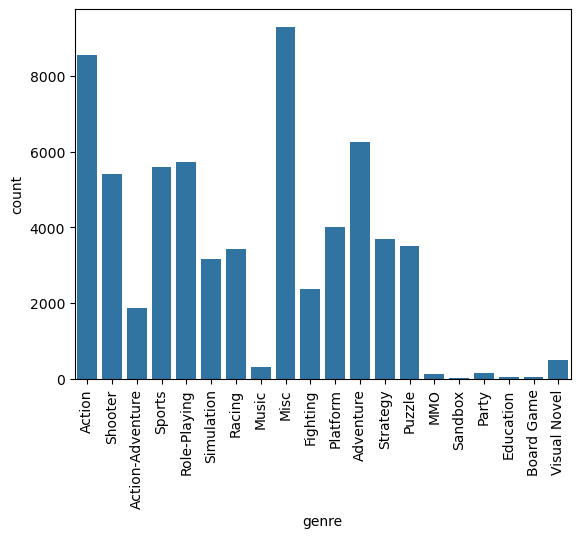

In [89]:
sns.countplot(data=df, x='genre')
plt.xticks(rotation=90)
plt.show()


# observation

1. Action and Shooter geners are published more.
2. Genere about education,board game and visual novel are published less.
3. From this we can see pepole prefer like action and shooter  genre video games more.

Top publishers by sales

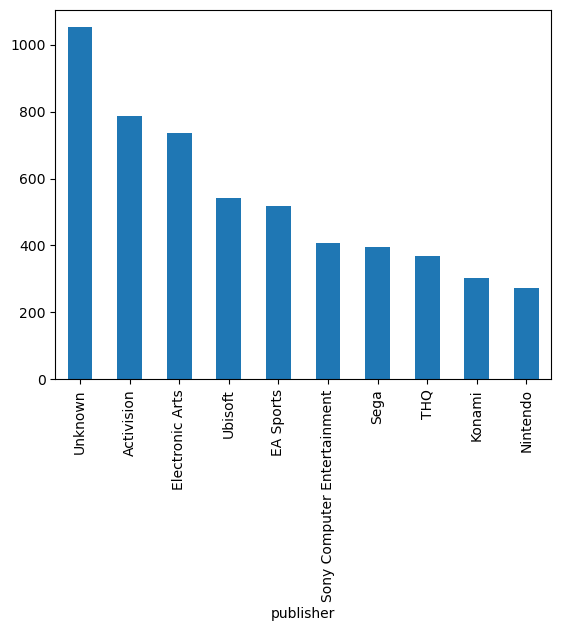

In [90]:
df.groupby('publisher')['total_sales(mil)'].sum().sort_values(ascending=False).head(10).plot.bar()
plt.show()


# observation

1. The Unknown and Activision and electronic Arts are top publisher compared to others.
2. The Unknown and Activision publisher sold around 800-1000 copies.

Top consoles by number of games

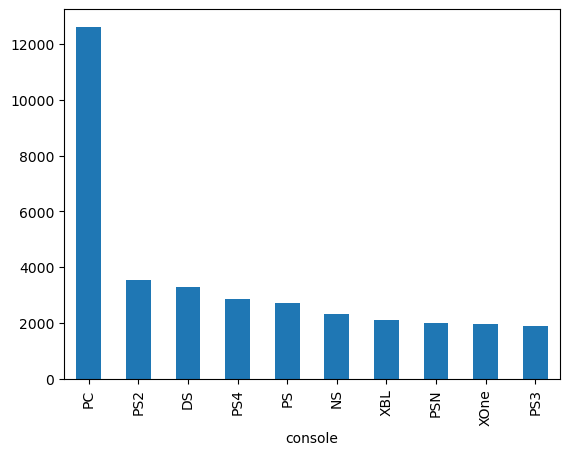

In [91]:
df['console'].value_counts().head(10).plot.bar()
plt.show()


# observation

1. To play video games people perfer PC and PS2 console more.
2. And we can also see that PC and PS2 offers better features and more compatibilty to play  video games.

Correlation Heatmap — which regions correlate with total sales

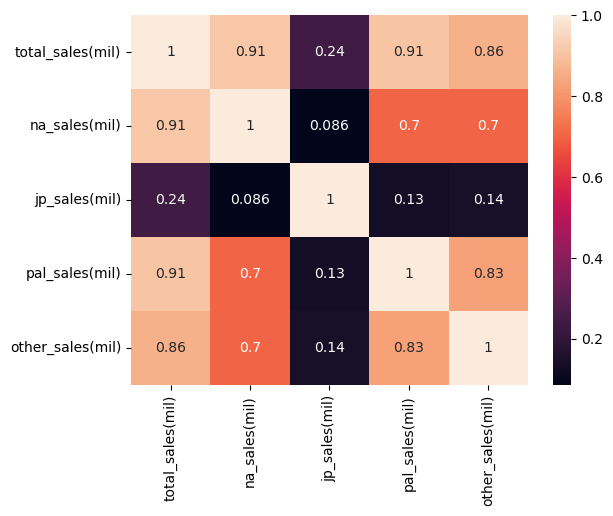

In [92]:
sns.heatmap(df[['total_sales(mil)','na_sales(mil)','jp_sales(mil)','pal_sales(mil)','other_sales(mil)']].corr(), annot=True)
plt.show()

Games released per year

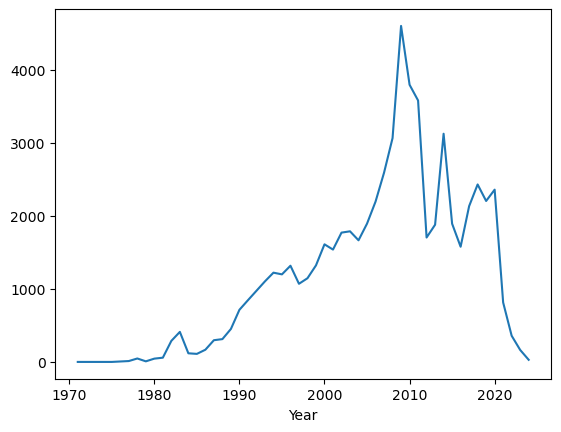

In [93]:
df['Year'].value_counts().sort_index().plot.line()
plt.show()


# observation

1. From Year 1970-1990 there is a less release of video games.
2. Around 2000 the release of viedo games are increased migth be because of lot of technological advancement and countinue till 2020.
3. From 2022 no new video games are released and has been gradually decresed.

Seasonal pattern — games by month

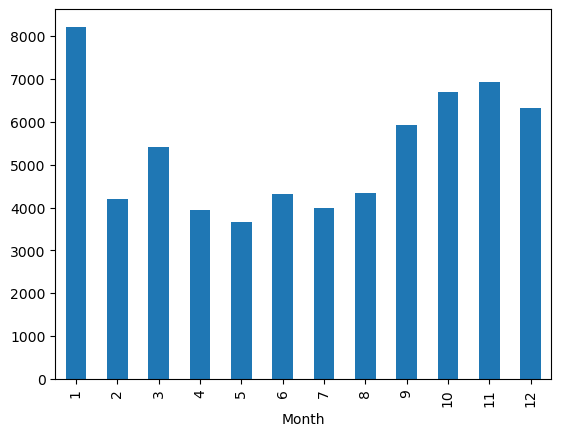

In [95]:
df['Month'].value_counts().sort_index().plot.bar()
plt.show()


# observation

1. Video games are released mostly reguraly every month but slightly more during the month of January.

Relationship between critic score & sales

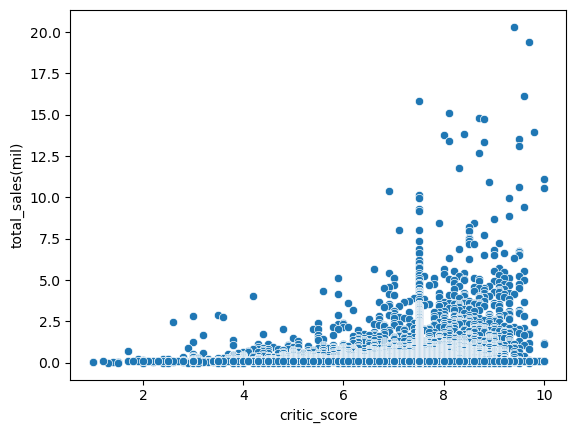

In [96]:
sns.scatterplot(data=df, x='critic_score', y='total_sales(mil)')
plt.show()


# Conclusion

1. Most video games sell very little, while only a few big titles make very high sales.
2. North America is the biggest market, with far higher sales than Japan or Europe.
3. Popular genres like Action, Sports, and Shooter dominate the number of game releases.
4. Major consoles such as PlayStation, Xbox, and Nintendo systems have the most games.
5. Higher critic scores usually lead to better sales, but not always.